In [1]:
import pandas as pd
import numpy as np
import matplotlib as pyplot

In [6]:
df = pd.read_csv("processed_bank_dataset.csv")

print(df.shape)
print(df.columns.tolist())
print(df.head())

(41188, 56)
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'marital_unknown', 'education_basic.6y', 'education_basic.9y', 'education_high.school', 'education_illiterate', 'education_professional.course', 'education_university.degree', 'education_unknown', 'default_unknown', 'default_yes', 'housing_unknown', 'housing_yes', 'loan_unknown', 'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_success', 'age_group', 'contacted_before', 'high_campaign']
        age  duration  cam

In [7]:
X = df.copy()

print("Shape:", X.shape)
print("Missing values:", X.isnull().sum().sum())
print("Data type check:")
print(X.dtypes.value_counts())

Shape: (41188, 56)
Missing values: 0
Data type check:
float64    56
Name: count, dtype: int64


In [8]:
#DBSCAN input
X = df.copy()

print("Shape:", X.shape)
print("Missing values:", X.isnull().sum().sum())
print("Data type check:")
print(X.dtypes.value_counts())

Shape: (41188, 56)
Missing values: 0
Data type check:
float64    56
Name: count, dtype: int64


In [9]:
#importing DBSCAN
from sklearn.cluster import DBSCAN

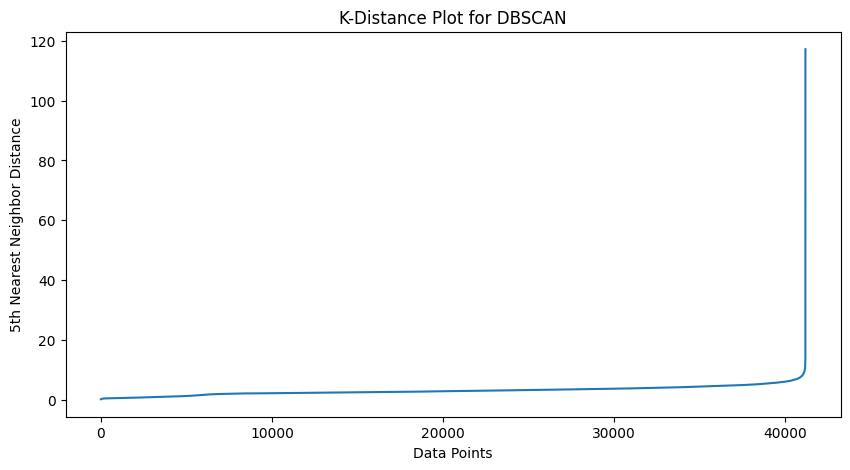

In [10]:
#ploting K-Distance plot
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X)

distances, indices = neighbors_fit.kneighbors(X)

distances = np.sort(distances[:, 4])

plt.figure(figsize=(10, 5))
plt.plot(distances)

plt.xlabel("Data Points")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Plot for DBSCAN")

plt.show()

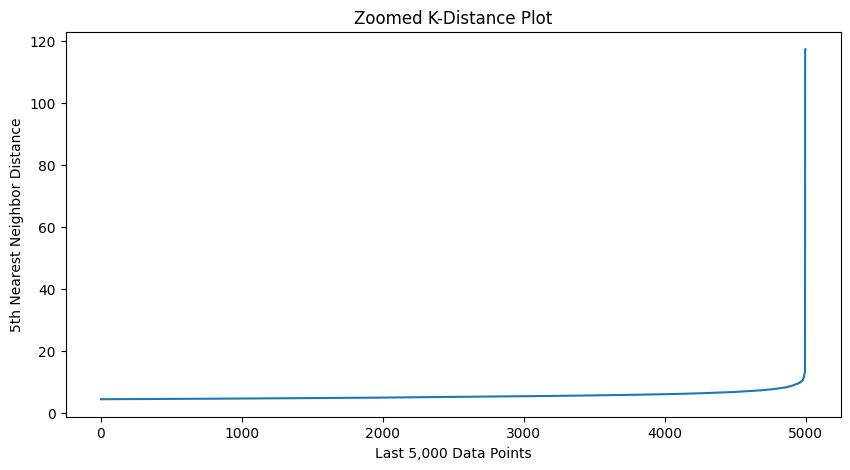

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(distances[-5000:])
plt.xlabel("Last 5,000 Data Points")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("Zoomed K-Distance Plot")
plt.show()

In [12]:
for p in [90, 95, 97, 98, 99, 99.5, 99.9, 100]:
    print(f"{p}% percentile: {np.percentile(distances, p):.3f}")

90% percentile: 4.703
95% percentile: 5.438
97% percentile: 5.934
98% percentile: 6.332
99% percentile: 7.101
99.5% percentile: 7.894
99.9% percentile: 9.862
100% percentile: 117.216


In [13]:
from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd

results = []

for eps in [5, 6, 7, 8, 9, 10]:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(X)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    noise_percent = (n_noise / len(labels)) * 100

    # Silhouette only makes sense if we have at least 2 clusters
    # and some non-noise observations.
    non_noise_mask = labels != -1

    if n_clusters >= 2 and np.sum(non_noise_mask) > 1:
        from sklearn.metrics import silhouette_score
        silhouette = silhouette_score(
            X[non_noise_mask],
            labels[non_noise_mask]
        )
    else:
        silhouette = np.nan

    results.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise_points": n_noise,
        "noise_percent": round(noise_percent, 2),
        "silhouette": silhouette
    })

results_df = pd.DataFrame(results)

results_df

,eps,clusters,noise_points,noise_percent,silhouette
0,5,82,1901,4.62,0.104214
1,6,46,606,1.47,0.154097
2,7,24,252,0.61,0.264031
3,8,13,117,0.28,0.285483
4,9,12,36,0.09,0.275439
5,10,7,17,0.04,0.344948


In [14]:
dbscan_final = DBSCAN(
    eps=10,
    min_samples=5
)

dbscan_labels = dbscan_final.fit_predict(X)

cluster_counts = pd.Series(dbscan_labels).value_counts().sort_index()

print(cluster_counts)

-1       17
 0    40584
 1      309
 2       65
 3        9
 4       17
 5      180
 6        7
Name: count, dtype: int64


In [15]:
from sklearn.metrics import silhouette_score

kmeans_silhouette = silhouette_score(
    X,
    sklearn_kmeans.labels_
)

print(f"K-Means Silhouette Score: {kmeans_silhouette:.4f}")

NameError: name 'sklearn_kmeans' is not defined